<h1><center><b> Simulacion de V.A. </b></center></h1>

Daremos recopilación de métodos para generar variables aleatorias utilizados en **Simulación Computacional**. Dado a que la forma iterativas son mas eficientes y programables en las computadoras; por otra parte nos quita la necesidad de utilizar las definiciones de las distribuciones para la generacion de datos como pseudoaleatorios para situaciones que requieran estas simulciones.

***Ejemplos comunes en simulación:***
- Tiempo entre llegada de cada persona  
- Número de personas por minuto  
- Número de artículos por persona  
- Cantidad de dinero ganado cada hora  
- Tiempo de atención por cliente  
- Número de veces que la cajera solicita ayuda durante la jornada  
- Cantidad de gente que está formada  
- Número de personas que pagan con tarjeta.


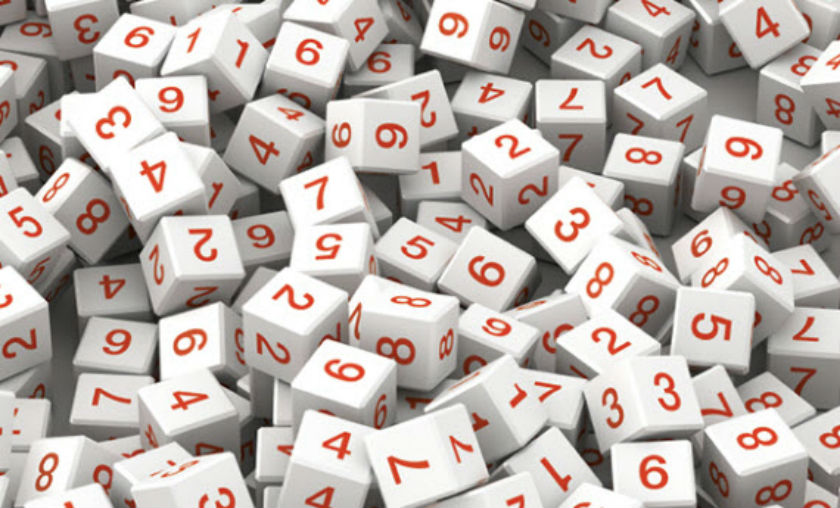

$\color{green}{\text{Conocimientos previos}}$

Se abordan distribuciones tales como: **uniformes**, **exponenciales**, **normales**, **binomiales** y **Poisson**, entre otras, así como técnicas como *la transformada inversa* y *el método del rechazo*.


## $\color{purple}{\text{Metodos de generacion de numeros aleatorios rectangulares}}$

La generación de variables aleatorias con esta distribución es importante porque las variables que tengan una distribución diferente, tendrán que usar a ésta como base.

$$ \color{red}{\text{Cada posible resultado entre $[a,b]$ tiene la misma probabilidad $1/n$.}} $$

**Las variables generadas deben cumplir con:**
- Los valores generados deben ser independientes y estar idénticamente distribuidos.
- La secuencia generada debe ser lo más larga posible y ser reproducibles.
- Debe permitir generar múltiples secuencias.
- Que usen poca memoria.

Históricamente se han usado cuatro tipos de métodos para generar sucesiones de números rectangulares:
- Métodos manuales
- Tablas de biblioteca
- Computación analógica
- Computación digital

**Generación pseudoaleatoria:**

La generación de los números aleatorios rectangulares debe realizarse a través de relaciones **matemáticas de recurrencia**. Por esta razón se consideran **pseudoaleatorios**, ya que el proceso para generarlos es **determinístico** *(donde el experimento ya esta sometido a muchas condiciones, del cual ya se sabe que hay un resultado unico)*...

Hay 2 métodos que son los más utilizados para la generación. Ambos se basan en la siguiente definición:

$ \color{red}{\text{Definicion:}} $

Dos enteros $a$ y $b$ son **congruentes módulo $m$** si su diferencia es un múltiplo entero de $m$ y se expresa como:

$$𝑎 \equiv 𝑏 ~ \text{𝑚o𝑑} ~ 𝑚$$

Como consecuencia:

- $(a-b)$ es divisible entre $m$.
- $a$ y $b$ dan el mismo residuo al ser divididos entre $m$.

### **Metodo Congruencial Multiplicativo**

Generar una secuencia de números pseudoaleatorios uniformes en el intervalo (0, 1) usando la siguiente fórmula recursiva:

$$ n_{i+1} = a n_{i} ~ \text{mod} ~ m $$

- $m:$ debe ser tan grande como sea posible, dependiendo de los bits por palabra que maneje la computadora, descontando el bit del signo ($b$). Por lo tanto: $m = 2^b$

- $a:$ debe satisfacer que $a \approx 2^{(b+1)/2}$ y que $a \equiv \pm 3 ~ \text{mod} ~ 8$. La segunda expresión equivale a $( a-(\pm3 ) )$ es múltiplo de $8$.

- $n_0:$ entero positivo impar menor a $m$

- El periodo será de longitud: $m/4$

In [ ]:
# --------------------------------------------------------------------------------

# Simulacion de numeros pseudoaleatorio por este metodo...

# --------------------------------------------------------------------------------

# definimos los parametros de la funcion:
      #     n0 : valor inicial o semilla
      #      a : multiplicador
      #      m : modulo (2^b)
      #      n : el número de numeros que quiero generar

def multiplicativo(n0,a,m,n):
    secuencia = []                # Lista que guarda los valores
    ni = n0                   # iniciar con una semilla

# Con este bucle hacemos que realice la formula, la agrega a la lista y prosigue con la recursitividad
    for _ in range(n):
        ni = (a * ni) % m         # calculo el sig numero utilizando la formula recurrente
        secuencia.append(ni/m)      # normaliza entre 0 y 1
    return secuencia

**Ejemplo:**

Generame 10 numeros con una semilla inicial del $12345$ por medio de **Metodo Congruencial Multiplicativo**...

In [ ]:
# establecemos el valor de los parametros para la funcion: "multiplicativo"

m = 2**31
a = 65539     # a ≡ +-3 mod 8
n0 = 12345
n = 10

In [ ]:
# Pasamos ver que nos devuelve este modelo

secuencia_mult = multiplicativo(n0,a,m,n)
print(secuencia_mult)

[0.37675674771890044, 0.2604887490160763, 0.17212176462635398, 0.6883318466134369, 0.5808951980434358, 0.29038456873968244, 0.5142506300471723, 0.4720426616258919, 0.20400029933080077, 0.9756178413517773]


Vamos a comparar ambas generacion de numero aleatorios entre **Metodo Congruencial Multiplicativo** y la **Distribucion Uniforme**....

In [ ]:
# traemos las siguientes paqueterias...

import numpy as np
import plotly.graph_objects as go     # Para gráficos interactivos

# Generamos ambas secuencias para la MCM y la Uniforme (usando los parametros anteriores)
secuencia_mult = multiplicativo(n0,a,m,n)
secuencia_numpy = np.random.uniform(0,1,n)

# figura con Plotly
fig = go.Figure()

# Añadir los histogramas para los numeros pseudoaleatorios
fig.add_trace(go.Histogram(
    x=secuencia_mult,
    nbinsx = 40,
    opacity = 0.6,
    name = 'Método multiplicativo',
    marker_color='red'
))

# Añadir los histogramas para los valores que nos genera la distribucion uniforme
fig.add_trace(go.Histogram(
    x=secuencia_numpy,
    nbinsx = 40,
    opacity = 0.6,
    name = 'Numpy random uniform',
    marker_color='blue'
))

# elementos de la grafica anterior...
fig.update_layout(
    barmode='overlay', #superpone los histogramas
    title = 'Compararación: Método multiplicativo -vs- Numpy',
    xaxis_title='valor generado',
    yaxis_title='Frecuencia',
    legend_title='Método',
    bargap=0.05
)

fig.show()

Podemos ver que lo que son los numeros generados en color rojo son nuestro numeros **Numeros Pseudoaleatorios**; mientras los numeros en azul son los generados por la **Distribucion Uniforme** *(dado por Numpy)*...

### **Método Congruencial Mixto**

Este método genera números pseudoaleatorios con la fórmula:
$$n_{i+1} = (a n_i + c) ~ \text{mod} ~ m$$

**Obsrvacion:** Se le llama “***mixto***” porque incluye una constante adicional $c$ y se estaria resolviendo con la multiplicacion e la suma.


- $m = 2^b$
- $a \approx 2^{(b-1)/2}$, $a \equiv 1 ~ \text{mod} ~ 4$
- $c$, $n_0$: enteros positivos impares $< m$
- Periodo: $m$

In [ ]:
# --------------------------------------------------------------------------------

# Simulacion de numeros pseudoaleatorio por este metodo...

# --------------------------------------------------------------------------------

# definimos los parametros de la funcion:
      #     n0 : valor inicial o semilla
      #      a : multiplicador
      #      c : constante impar
      #      m : modulo (2^b)
      #      n : el número de numeros que quiero generar

def mixto(n0,a,c,m,n):
    secuencia = []        # Lista que guarda los valores
    ni = n0               # iniciar con una semilla

# Con este bucle hacemos que realice la formula, la agrega a la lista y prosigue con la recursitividad
    for _ in range(n):
        ni = (a * ni + c) % m       # calculo el sig numero utilizando la formula recurrente
        secuencia.append(ni/m)          # normaliza entre 0 y 1
    return secuencia

In [ ]:
# Pasamos ver que nos devuelve este modelo
m = 2**31
a = 1103515245 # a cong 1 mod----
c = 12345
n0 = 42
n= 10

In [ ]:
secuencia_mixto = mixto(n0,a,c,m,n)
print(secuencia_mixto)

[0.5823075897060335, 0.5198187492787838, 0.46597642498090863, 0.7770372582599521, 0.42286502895876765, 0.03337232954800129, 0.41738913068547845, 0.8087285170331597, 0.6123396842740476, 0.7149040475487709]


In [ ]:
# Generamos ambas secuencias para la MCM_1 y la Uniforme (usando los parametros anteriores)

# Generamos ambas secuencias
secuencia_mixto = mixto(n0,a,c,m,n)
secuencia_numpy = np.random.uniform(0,1,n)

# figura con Plotly
fig = go.Figure()

# Añadir los histogramas para los numeros pseudoaleatorios
fig.add_trace(go.Histogram(
    x=secuencia_mixto,
    nbinsx = 40,
    opacity = 0.6,
    name = 'Método mixto',
    marker_color='red'
))

# Añadir los histogramas para los valores que nos genera la distribucion uniforme
fig.add_trace(go.Histogram(
    x=secuencia_numpy,
    nbinsx = 40,
    opacity = 0.6,
    name = 'Numpy random uniform',
    marker_color='blue'
))

# elementos de la grafica anterior...
fig.update_layout(
    barmode='overlay', #superpone los histogramas
    title = 'Compararación: Método mixto -vs- Numpy',
    xaxis_title='valor generado',
    yaxis_title='Frecuencia',
    legend_title='Método',
    bargap=0.05
)

fig.show()

Estos metodos soin buenos a la hora de generar numeros psedoaleatoria, pero no es perfecto; cada uno de ellos tiene su ventaje e desventajas...


| **Método**     | **Fórmula**                            | **Ventajas**                                          | **Riesgos / Limitaciones**                                |
|----------------|----------------------------------------|-------------------------------------------------------|------------------------------------------------------------|
| Multiplicativo | $ n_{i+1} = a n_i ~ \text{mod} ~ m $           | Rápido, menos memoria                                 | Menor aleatoriedad, requiere \( a, m, n_0 \) bien elegidos |
| Mixto          | $ n_{i+1} = (a n_i + c) ~ \text{mod} ~ m $     | Mejor distribución, periodo completo posible          | Más complejo, pero más robusto                             |
| NumPy (`uniform`) | Motor moderno y validado           | Alta calidad, probado, rápido                         | Caja negra, sin control del generador interno              |

Ahora comparemos con la generacion de numeros pero con respecto a la paqueteria que siempre ocupamos...


### **Numeros Psedoaleatoria de "*Numpy_Ramdom* "**

In [ ]:
# Traemos la paqueteria "Ramdom" que nos ofrece Python...
import random

# El parametro que indica el numero de datos aleatoria que deseamos
n = 1000

# Generar secuencia usando random.random()
secuencia_random = [random.random() for _ in range(n)]

# Generar secuencia usando numpy
secuencia_numpy = np.random.uniform(0, 1, n)

# Graficar histogramas
fig = go.Figure()

# Añadir los histogramas para los valores que nos genera la paqueteria "Random"
fig.add_trace(go.Histogram(
    x=secuencia_random,
    nbinsx=40,
    opacity=0.6,
    name='random.random()',
    marker_color='crimson'
))

# Añadir los histogramas para los valores que nos genera la distribucion uniforme
fig.add_trace(go.Histogram(
    x=secuencia_numpy,
    nbinsx=40,
    opacity=0.6,
    name='numpy.random.uniform',
    marker_color='royalblue'
))

# elementos de la grafica anterior...
fig.update_layout(
    barmode='overlay',
    title='Comparación: random.random() vs numpy.random.uniform',
    xaxis_title='Valor generado',
    yaxis_title='Frecuencia',
    legend_title='Método',
    bargap=0.05
)

fig.show()

## $\color{purple}{\text{Metodo de la transformada inversa}}$

El método utiliza la función de distribución $F(x)$ de la distribución que se va a simular, que por definicion tenemos que:

$$F(x) = \int_{-\infty}^{x} f(t)\,dt$$

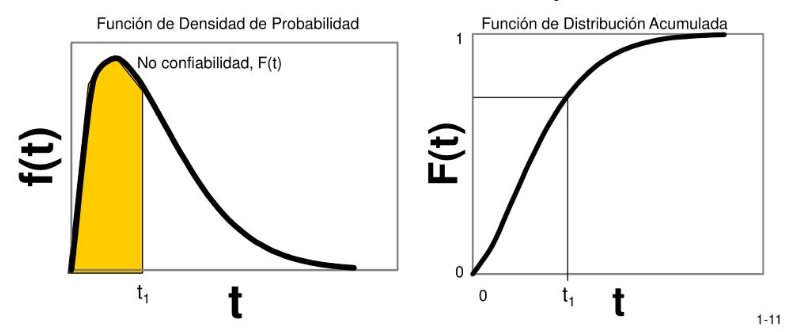

Como se sabe, los valores de $F(x)$ están en el intervalo $(0,1)$ al igual que los números rectangulares $U$.

El método genera un $U$ y trata de determinar el valor de la variable aleatoria para la cual $F(x)$ sea igual a $U$.

Si $U \in (0,1)$:
$$ F(x) = U \quad \Rightarrow \quad x = F^{-1}(U)$$

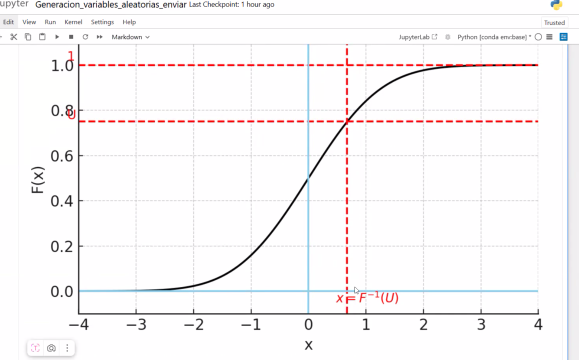

$\color{blue}{Teorema:}$

Sea $X$ una variable aleatoria real. Supongamos que su función de distribución $F$ es estrictamente creciente. Sea $U\sim \text{unif}[0,1]$. Entonces $F^{-1}(U)$ tiene la misma ley que $X$.

---

**Nota:** Por lo que $F$ es una biyección de $\mathbb{R}$ sobre $(0,1)$ y podemos denotar por $F^{-1}$ a su inversa.

---

Si $F$ no es estrictamente creciente, hemos visto que el teorema precedente sigue siendo válido bajo la condición de definir:

$$F^{-1}(u)=\inf\{ x\in \mathbb{R} : F(x)\geq u\}$$

La inversa generalizada de $F$.

### **Ejemplo:** $\text{Con la Distribucion Bernoulli}$

In [ ]:
# --------------------------------------------------------------------------------

# Simulacion de n valores de la bernoulli.

# --------------------------------------------------------------------------------

# Importamos la paqueteria "Random"
import random

# definimos una funcion y que nos devuelva 1 si se cumple la desigulada
def bernoulli(p):
    u = random.random()     # U -> Unif(0,1)
    return 1 if u <= p else 0

In [ ]:
# Simulamos n valores con p de éxito
p = 0.5

# Guardamos los resultados en uns lista
simulaciones = [bernoulli(p) for _ in range(100)]
print(simulaciones)

[1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1]


In [ ]:
# Vemos cuantos resultados salieron positivos.
sum(simulaciones)

49

### **Ejemplo:** $\text{Con la Distribucion Exponencial}$

Sea $\lambda>0$ ; entonces a través del teorema, se puede generar una **V.A.** Exponencial.

Sea $U \sim Unif[0,1]$; entonces si $X \sim exp(\lambda)$, entonces:

$$ f_{X}(x) = \lambda e^{-\lambda x} ~ ~ ~ ~ ~ ~ ~ \text{y} ~ ~ ~ ~ ~ ~ ~ F_X(x) = 1-e^{-\lambda x} $$

Realizado la igualdad tenemos que:

$$ 1-e^{-\lambda x} = U ~ \Rightarrow ~ 1-U = e^{-\lambda x} ~ \Rightarrow ~ \ln(1-U) = -\lambda x ~ \Rightarrow ~ - \frac{\ln(1 - U)}{\lambda} + x $$

Por lo tanto tenemos que:

$$ -\frac{\ln(U)}{\lambda} \sim Exp(\lambda) $$

Pasemos a verlo graficamente los numeros psedoaleatorios que genera...

In [ ]:
# --------------------------------------------------------------------------------

# Simulacion de n valores de la Exponencial.

# --------------------------------------------------------------------------------


# Traemos la paqueteria para la simulacion
import numpy as np
import plotly.graph_objects as go

# Semilla
np.random.seed(123)

# Parámetro de la exponencial
lambd = 4

# La cantidad de numeros a conseguir
n = 10000

# Simulación usando transformada inversa
uniformes = np.random.random(n)
exponenciales = -np.log(uniformes) / lambd     # Usamos la formula que determinamos

# Curva teórica
x_vals = np.linspace(0, exponenciales.max(), 300)
y_vals = lambd * np.exp(-lambd * x_vals)

# Gráfico
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=exponenciales,
    nbinsx=40,
    histnorm='probability density',
    marker_color='skyblue',
    name='Simulación'
))

fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode='lines',
    name='Densidad teórica',
    line=dict(color='darkblue')
))

fig.update_layout(
    title='Distribución Exponencial simulada vs teórica (λ = 1)',
    xaxis_title='x',
    yaxis_title='Densidad',
    bargap=0.05
)

fig.show()

### **Ejemplo:** $\text{Con la Distribucion Uniforme Continua}$

Sea $U \sim Unif[0,1]$; entonces si $X \sim Unif(a,b)$, entonces:

$$ f_{X}(x) =  \frac{1}{b-a} ~ ~ ~ ~ ~ ~ ~ \text{y} ~ ~ ~ ~ ~ ~ ~ F_X(x) = \frac{x-a}{b-a} $$

Realizado la igualdad tenemos que:

$$ \frac{x-a}{b-a} = U ~ \Rightarrow ~ x-a = U(b-a) ~ \Rightarrow ~ x = U(b-a) + a $$

Por lo tanto tenemos que:

$$ U(b-a) + a \sim Unif(a,b) $$

Pasemos a verlo graficamente los numeros psedoaleatorios que genera...

In [ ]:
# --------------------------------------------------------------------------------

# Simulacion de n valores de la Uniforme Continua.

# --------------------------------------------------------------------------------

# Traemos la paqueteria para la simulacion
import numpy as np
import plotly.graph_objects as go


# Parámetros de la uniforme
a, b = 2, 5
n = 10000

# Simulación por transformación lineal
uniformes = np.random.random(n)
uniforme_continua = a + (b - a) * uniformes

# Densidad teórica (constante)
x_vals = np.linspace(a, b, 300)
y_vals = np.ones_like(x_vals) * (1 / (b - a))

# Gráfico
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=uniforme_continua,
    nbinsx=40,
    histnorm='probability density',
    marker_color='orange',
    name='Simulación'
))

fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode='lines',
    name='Densidad teórica',
    line=dict(color='red')
))

fig.update_layout(
    title='Distribución Uniforme Continua simulada vs teórica [2, 5]',
    xaxis_title='x',
    yaxis_title='Densidad',
    bargap=0.05
)

fig.show()

### **Ejemplo:** $\text{Con la Distribucion Cauchy Estandar}$

Sea $U \sim Unif[0,1]$; entonces si $X \sim Unif(a,b)$, entonces:

$$ f_{X}(x) = \frac{1}{\pi (1 + x^2)} ~ ~ ~ ~ ~ ~ ~ \text{y} ~ ~ ~ ~ ~ ~ ~ F_{X}(x) = \frac{1}{\pi} \arctan(x) + \frac{1}{2} $$

Realizado la igualdad tenemos que:

$$ \frac{1}{\pi} \arctan(x) + \frac{1}{2} = U ~ \Rightarrow ~ \frac{1}{\pi} \arctan(x) = U - \frac{1}{2} ~ \Rightarrow ~ $$

$$ \arctan(x) = \pi \left( U - \frac{1}{2} \right) ~ \Rightarrow ~ x = \tan \left( \pi \left( U - \frac{1}{2} \right) \right) $$

Por lo tanto tenemos que:

$$ \tan \left( \pi \left( U - \frac{1}{2} \right) \right) \sim Cauchy(0,1) $$

Pasemos a verlo graficamente los numeros psedoaleatorios que genera...

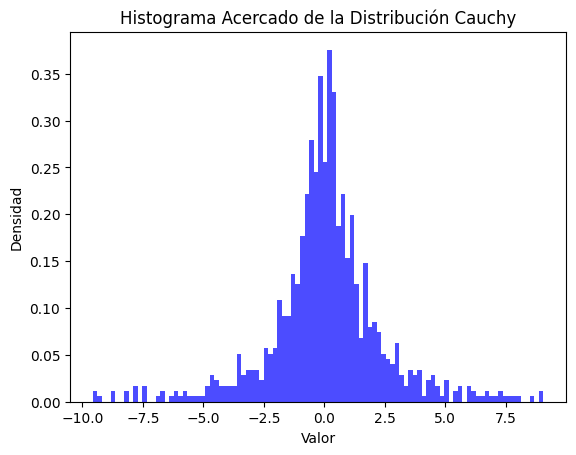

In [ ]:
# --------------------------------------------------------------------------------

# Simulacion de n valores de la Cauchy.

# --------------------------------------------------------------------------------

# Traemos la paqueteria para la simulacion
import numpy as np
import matplotlib.pyplot as plt

# Generar una variable aleatoria Cauchy
def generar_cauchy(n):
    U = np.random.uniform(0, 1, n)  # n valores uniformes
    X = np.tan(np.pi * (U - 0.5))  # Aplicar la fórmula
    return X

# Generar 1000 muestras de la distribución Cauchy
muestras_cauchy = generar_cauchy(1000)

# Filtrar valores extremos para centrarse en una parte más visible
muestras_centrales = muestras_cauchy[np.abs(muestras_cauchy) < 10]

# Crear un histograma de las muestras filtradas
plt.hist(muestras_centrales, bins=100, density=True, alpha=0.7, color='blue')

plt.title('Histograma Acercado de la Distribución Cauchy')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.show()
